# Intro: **Histogram Equalization** (CPU & GPU)

Histogram equalization improves contrast by redistributing pixel intensities using the cumulative distribution function.

Objective:
To implement histogram equalization from scratch using:
- NumPy (CPU)
- Numba CUDA (GPU implementation)

Done by: Siddharth S. (25901335)

# **Download & Install Libraries**

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import time

from numba import cuda

# **Load Image**

In [4]:
from google.colab import files

uploaded = files.upload()

Saving Starry_Night.jpg to Starry_Night.jpg


(np.float64(-0.5), np.float64(499.5), np.float64(395.5), np.float64(-0.5))

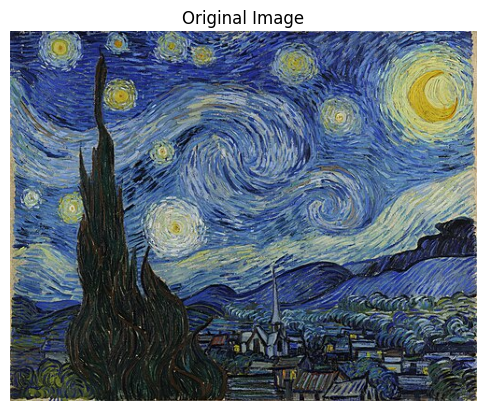

In [5]:
img = cv2.imread(list(uploaded.keys())[0])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Original Image")
plt.axis('off')

# **Grayscale** Histogram Equalization

## CPU

In [6]:
def hist_eq_gray_numpy(image):
    h, w = image.shape

    flat = image.flatten()

    hist = np.zeros(256)
    for pixel in flat:
        hist[pixel] += 1

    # CDF
    cdf = np.cumsum(hist)
    # Normalize
    cdf = cdf / (h * w)
    # Mapping
    mapping = np.floor(255 * cdf).astype(np.uint8)

    equalized = mapping[flat].reshape((h, w))

    return equalized

CPU Time: 0.13107705116271973


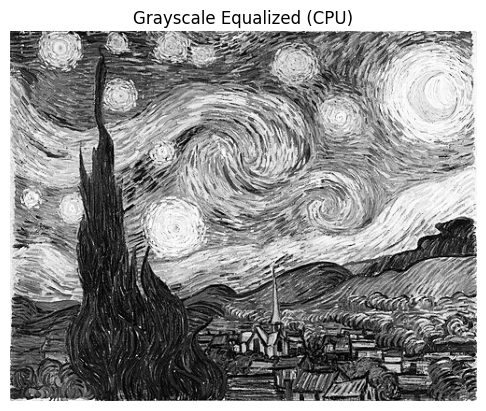

In [7]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

start = time.time()
gray_eq_cpu = hist_eq_gray_numpy(gray)
cpu_time = time.time() - start

plt.imshow(gray_eq_cpu, cmap='gray')
plt.title("Grayscale Equalized (CPU)")
plt.axis('off')

print("CPU Time:", cpu_time)

## GPU

### Histogram Kernel

In [8]:
@cuda.jit
def compute_histogram(image, hist):
    i, j = cuda.grid(2)
    if i < image.shape[0] and j < image.shape[1]:
        val = image[i, j]
        cuda.atomic.add(hist, val, 1)

### Mapping Kernel

In [9]:
@cuda.jit
def apply_mapping(image, mapping, out):
    i, j = cuda.grid(2)
    if i < image.shape[0] and j < image.shape[1]:
        out[i, j] = mapping[image[i, j]]

### Pipeline

In [10]:
def hist_eq_gray_cuda(image):
    h, w = image.shape

    d_img = cuda.to_device(image)
    d_hist = cuda.to_device(np.zeros(256, dtype=np.int32))

    threads = (16, 16)
    blocks = ((h + 15)//16, (w + 15)//16)

    compute_histogram[blocks, threads](d_img, d_hist)
    hist = d_hist.copy_to_host()

    # CDF
    cdf = np.cumsum(hist) / (h * w)
    mapping = np.array(255 * cdf, dtype=np.uint8)

    d_map = cuda.to_device(mapping)
    d_out = cuda.device_array((h, w), dtype=np.uint8)


    apply_mapping[blocks, threads](d_img, d_map, d_out)

    return d_out.copy_to_host()

GPU Time: 2.2058510780334473


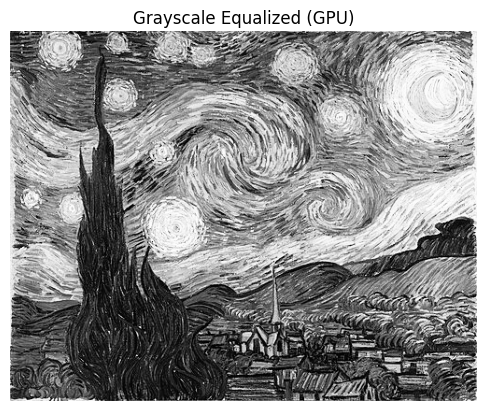

In [11]:
start = time.time()
gray_eq_gpu = hist_eq_gray_cuda(gray)
gpu_time = time.time() - start

plt.imshow(gray_eq_gpu, cmap='gray')
plt.title("Grayscale Equalized (GPU)")
plt.axis('off')

print("GPU Time:", gpu_time)

# **Color** Image Equalization **(RGB)**

In [12]:
def hist_eq_rgb(image):
    out = np.zeros_like(image)

    for c in range(3):
        out[:, :, c] = hist_eq_gray_numpy(image[:, :, c])

    return out

(np.float64(-0.5), np.float64(499.5), np.float64(395.5), np.float64(-0.5))

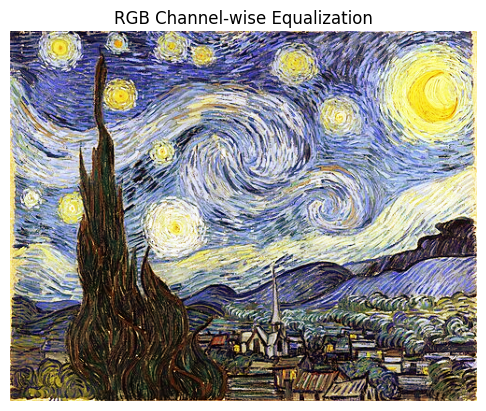

In [13]:
rgb_eq = hist_eq_rgb(img)

plt.imshow(rgb_eq)
plt.title("RGB Channel-wise Equalization")
plt.axis('off')

# **Histogram Computation**

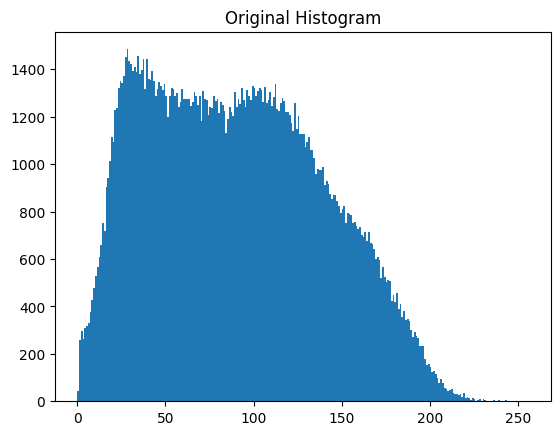

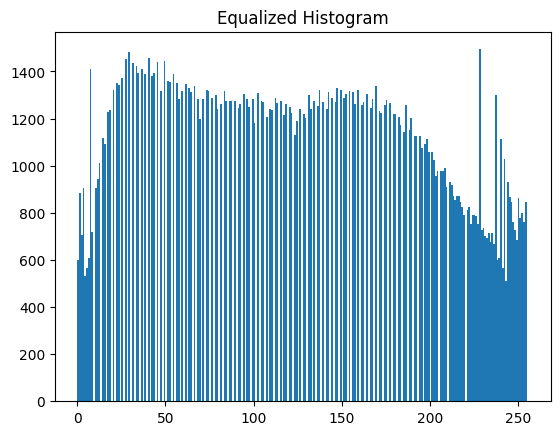

In [14]:
def plot_hist(image, title):
    plt.hist(image.flatten(), bins=256, range=[0,256])
    plt.title(title)
    plt.show()

plot_hist(gray, "Original Histogram")
plot_hist(gray_eq_cpu, "Equalized Histogram")

# **Performance Comparison**

In [15]:
print(f"CPU (NumPy): {cpu_time:.5f} sec")
print(f"GPU (CUDA): {gpu_time:.5f} sec")

CPU (NumPy): 0.13108 sec
GPU (CUDA): 2.20585 sec


Although GPU parallelization is generally faster, in this case the CUDA implementation was slower than the CPU implementation.

Reasons:

1. Data transfer overhead between CPU and GPU dominates execution time.
2. Histogram computation requires atomic operations, causing thread contention.
3. The input image size is relatively small, limiting parallel efficiency.

GPU acceleration becomes beneficial only for large-scale or batch processing tasks.